# Test with a real data

In [1]:
import xarray as xr
import glob

from pcmdi_metrics.effective_resolution import compute_effective_resolution
import matplotlib.pyplot as plt
import numpy as np

## Prepare input

In [2]:
datadir = "/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/MPI-ESM1-2-XR/highresSST-present/6hrPlevPt"

In [3]:
data_list = sorted(glob.glob(f"{datadir}/*/*MPI-ESM1-2-XR*_2014*.nc"))
data_list

['/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/MPI-ESM1-2-XR/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_MPI-ESM1-2-XR_highresSST-present_r1i1p1f1_gn_201401010558-201412312358.nc',
 '/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/MPI-ESM1-2-XR/highresSST-present/6hrPlevPt/va/va_6hrPlevPt_MPI-ESM1-2-XR_highresSST-present_r1i1p1f1_gn_201401010558-201412312358.nc']

In [4]:
target_months = ('201403', '201406', '201409', '201412')

data_list = [
    data_path
    for data_path in data_list
    if any(month in data_path for month in target_months)
]

In [5]:
[filepath.split('/')[-1] for filepath in data_list]

['ua_6hrPlevPt_MPI-ESM1-2-XR_highresSST-present_r1i1p1f1_gn_201401010558-201412312358.nc',
 'va_6hrPlevPt_MPI-ESM1-2-XR_highresSST-present_r1i1p1f1_gn_201401010558-201412312358.nc']

In [6]:
ds = xr.open_mfdataset(data_list)

/tmp/ipykernel_1773310/1960847013.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(data_list)
/tmp/ipykernel_1773310/1960847013.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(data_list)


In [7]:
ds

<xarray.Dataset> Size: 24GB
Dimensions:   (lon: 768, bnds: 2, lat: 384, time: 1460, plev: 7)
Coordinates:
  * lon       (lon) float64 6kB 0.0 0.4688 0.9375 1.406 ... 358.6 359.1 359.5
  * lat       (lat) float64 3kB -89.64 -89.18 -88.71 ... 88.71 89.18 89.64
  * time      (time) datetime64[ns] 12kB 2014-01-01T05:58:00 ... 2014-12-31T2...
  * plev      (plev) float64 56B 9.25e+04 8.5e+04 7e+04 ... 5e+04 2.5e+04 5e+03
Dimensions without coordinates: bnds
Data variables:
    lon_bnds  (lon, bnds) float64 12kB dask.array<chunksize=(768, 2), meta=np.ndarray>
    lat_bnds  (lat, bnds) float64 6kB dask.array<chunksize=(384, 2), meta=np.ndarray>
    ua        (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 1, 384, 768), meta=np.ndarray>
    va        (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 1, 384, 768), meta=np.ndarray>
Attributes: (12/36)
    realm:                      atmos
    frequency:                  6hr
    creation_date:              2017-05-11T18:41:34Z
    activity_id:                HighResMIP
    description:                Forced global atmosphere-land simulations usi...
    experiment:                 forced atmosphere experiment for 1950-2014
    ...                         ...
    nco_openmp_thread_number:   1
    NCO:                        4.7.3
    history_of_appended_files:  Sat Oct 26 09:06:13 2019: Appended file /gws/...
    tracking_id:                hdl:21.14100/da0174d0-e6e4-4c03-ae95-d99821d8...
    external_variables:         areacella
    history:                    Sat Oct 26 09:06:13 2019: ncks -A -v lat_bnds...

## Metrics calculation

Takes ~2 min

In [8]:
%%time

metrics, diagnostics = compute_effective_resolution(
    ds,
    uvar="ua",
    vvar="va",
    levels=(250.0, 500.0),
    model="MPI-ESM1-2-XR",
    member="r1i1p1f1",
    save_interim_netcdf=False,
)

result = metrics["MPI-ESM1-2-XR"]["r1i1p1f1"]
result

CPU times: user 6h 7min 24s, sys: 50.8 s, total: 6h 8min 15s
Wall time: 46min 19s


{'effective_wavenumber': 87.0,
 'effective_resolution_km': 228.7475837822945,
 'grid_box_distance_km': 66.94555429820669,
 'resolution_ratio': 3.416919707070408,
 'resolution_ratio_dx_convention': 9.664508382557749,
 'is_upper_limit': False,
 'n_spectra_steepening': 3,
 'steepening_wavenumber': {'div_250': 82.0, 'rot_250': 107.0, 'rot_500': 87.0},
 'steepening_eddy_scale_km': {'div_250': 242.61156839614054,
  'rot_250': 186.1888678686051,
  'rot_500': 228.7475837822945},
 'steepening_wavenumber_range': [82.0, 107.0],
 'criterion': {'fit_window': 20,
  'fit_anchor': 'right',
  'steepening_factor': 0.25,
  'wavenumber_ratio': 2.0,
  'min_wavenumber': 32,
  'n_confirm': 2},
 'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}

Save interim fime for cross validation (takes longer time ~8 min)

In [9]:
"""
%%time

metrics, diagnostics = compute_effective_resolution(
    ds,
    uvar="ua",
    vvar="va",
    levels=(250.0, 500.0),
    model="MPI-ESM1-2-XR",
    member="r1i1p1f1",
    save_interim_netcdf=True,
)

result = metrics["MPI-ESM1-2-XR"]["r1i1p1f1"]
result
"""

'\n%%time\n\nmetrics, diagnostics = compute_effective_resolution(\n    ds,\n    uvar="ua",\n    vvar="va",\n    levels=(250.0, 500.0),\n    model="MPI-ESM1-2-XR",\n    member="r1i1p1f1",\n    save_interim_netcdf=True,\n)\n\nresult = metrics["MPI-ESM1-2-XR"]["r1i1p1f1"]\nresult\n'

## Analysis (temporary interim data)

## Analysis (diagnostics)

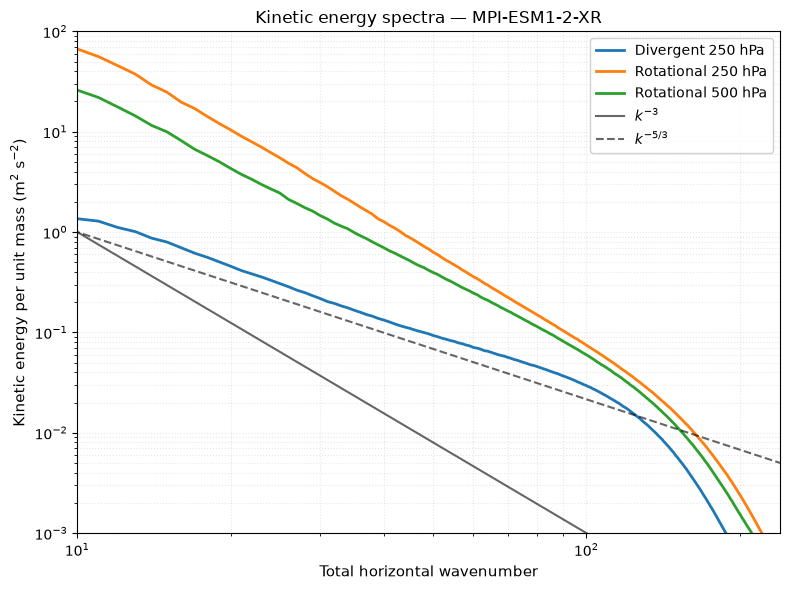

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the kinetic energy spectra
spectra = diagnostics["spectra"]
colors = {"div": "C0", "rot_250": "C1", "rot_500": "C2"}
labels = {"div": "Divergent 250 hPa", "rot_250": "Rotational 250 hPa", 
          "rot_500": "Rotational 500 hPa"}

# Plot divergent at 250 hPa
spec_250 = spectra[250.0]
wavenumber = spec_250["wavenumber"].values
ke_div = spec_250["ke_div"].values
ax.loglog(wavenumber, ke_div, color=colors["div"], linewidth=2, label=labels["div"])

# Plot rotational at 250 hPa
ke_rot_250 = spec_250["ke_rot"].values
ax.loglog(wavenumber, ke_rot_250, color=colors["rot_250"], linewidth=2, label=labels["rot_250"])

# Plot rotational at 500 hPa
spec_500 = spectra[500.0]
ke_rot_500 = spec_500["ke_rot"].values
ax.loglog(wavenumber, ke_rot_500, color=colors["rot_500"], linewidth=2, label=labels["rot_500"])

# Add reference lines for k^-3 and k^-5/3
# Control where reference lines start by specifying y-value at a reference wavenumber
k_ref_start = 10.0       # Reference wavenumber where we set the y-value
y_ref_value = 1e0        # Y-axis value at k_ref_start for both reference lines

k_ref = np.logspace(0, 3, 100)  # wavenumbers from 1 to 1000

# Calculate amplitude to make reference line pass through (k_ref_start, y_ref_value)
# For k^-3: y = A * k^-3, so A = y * k^3
amplitude_k3 = y_ref_value * k_ref_start**3
amplitude_k53 = y_ref_value * k_ref_start**(5/3)

ke_ref_k3 = amplitude_k3 * k_ref**(-3)
ke_ref_k53 = amplitude_k53 * k_ref**(-5/3)

ax.loglog(k_ref, ke_ref_k3, 'k-', linewidth=1.5, alpha=0.6, label=r'$k^{-3}$')
ax.loglog(k_ref, ke_ref_k53, 'k--', linewidth=1.5, alpha=0.6, label=r'$k^{-5/3}$')

ax.set_xlim(10, 240)
ax.set_ylim(1e-3, 1e2)
ax.set_xlabel("Total horizontal wavenumber", fontsize=11)
ax.set_ylabel(r"Kinetic energy per unit mass (m$^2$ s$^{-2}$)", fontsize=11)
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
ax.grid(True, which="both", alpha=0.3, linestyle=":")
ax.set_title("Kinetic energy spectra — MPI-ESM1-2-XR", fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
metrics

{'MPI-ESM1-2-XR': {'r1i1p1f1': {'effective_wavenumber': 87.0,
   'effective_resolution_km': 228.7475837822945,
   'grid_box_distance_km': 66.94555429820669,
   'resolution_ratio': 3.416919707070408,
   'resolution_ratio_dx_convention': 9.664508382557749,
   'is_upper_limit': False,
   'n_spectra_steepening': 3,
   'steepening_wavenumber': {'div_250': 82.0,
    'rot_250': 107.0,
    'rot_500': 87.0},
   'steepening_eddy_scale_km': {'div_250': 242.61156839614054,
    'rot_250': 186.1888678686051,
    'rot_500': 228.7475837822945},
   'steepening_wavenumber_range': [82.0, 107.0],
   'criterion': {'fit_window': 20,
    'fit_anchor': 'right',
    'steepening_factor': 0.25,
    'wavenumber_ratio': 2.0,
    'min_wavenumber': 32,
    'n_confirm': 2},
   'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}}}

### Compensated vs. Uncompensated Spectra

The `plot_spectra_and_slope` function supports both:

1. **Compensated spectra** (default, `compensate=3.0`): Reproduces Figure 1 from Klaver et al. (2020)
   - Y-axis shows $l^3 E_l$, making a $k^{-3}$ spectrum appear flat
   - Highlights deviations from the reference power laws
   - Easier to see spectral steepening

2. **Uncompensated spectra** (`compensate=None` or `compensate=0`): Reproduces Figure S3 from supplementary material
   - Y-axis shows raw spectrum in m²/s²
   - Power-law slopes appear as straight lines in log-log space
   - Shows the full dynamic range of the spectra

Both styles show the same data but emphasize different aspects of the spectral behavior.

In [12]:
from pcmdi_metrics.effective_resolution.lib import (
    plot_spectra_and_slope,
)

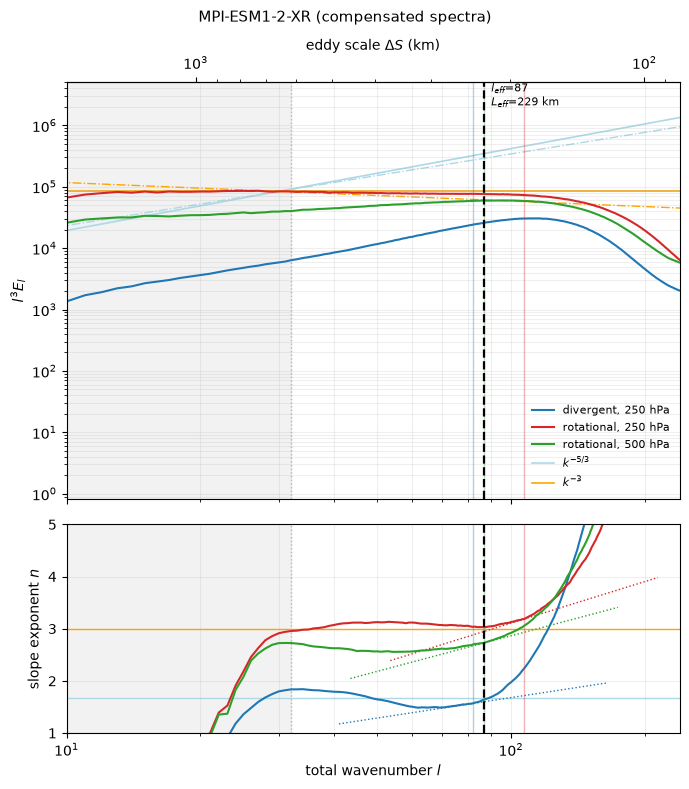

In [13]:
# Test uncompensated spectra (Figure S3 style)
# Set compensate=None or compensate=0 to plot without l^-3 compensation
fig = plot_spectra_and_slope(
    diagnostics, 
    result,
    #compensate=None,         # Turn OFF compensation (Figure S3)
    xlim=(10, 240),          # Wavenumber range
    #spec_ylim=(1e-2, 1e2),   # Uncompensated spectrum y-range
    slope_ylim=(1, 5),       # Slope panel y-range
    title="MPI-ESM1-2-XR (compensated spectra)"
)
plt.show()

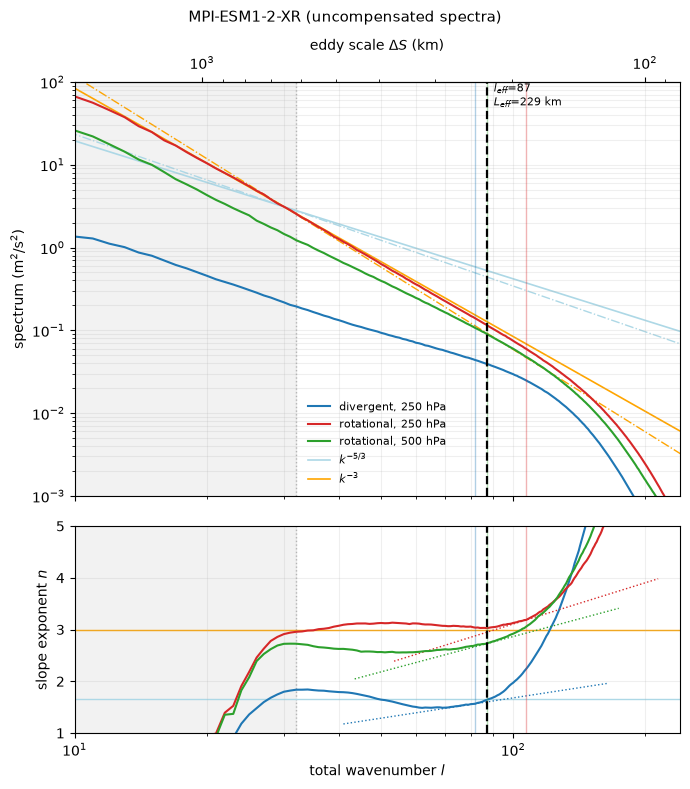

In [14]:
# Test uncompensated spectra (Figure S3 style)
# Set compensate=None or compensate=0 to plot without l^-3 compensation
fig = plot_spectra_and_slope(
    diagnostics, 
    result,
    compensate=None,         # Turn OFF compensation (Figure S3)
    xlim=(10, 240),          # Wavenumber range
    spec_ylim=(1e-3, 1e2),   # Uncompensated spectrum y-range
    slope_ylim=(1, 5),       # Slope panel y-range
    title="MPI-ESM1-2-XR (uncompensated spectra)"
)
plt.show()

## Figure 2 — Effective vs. Nominal Resolution Scatter Plot

This reproduces Figure 2 from Klaver et al. (2020), showing the relationship between effective resolution (L_eff) and grid box distance (L_box). The ratio L_eff/L_box is color-coded and ranges from 2.7 to 4.8 across the HighResMIP models in the paper.

**Note**: This example shows only one configuration (MPI-ESM1-2-XR regridded to 1°). The scatter plot is most useful when comparing multiple models or resolution configurations of the same model (e.g., LR vs HR versions).

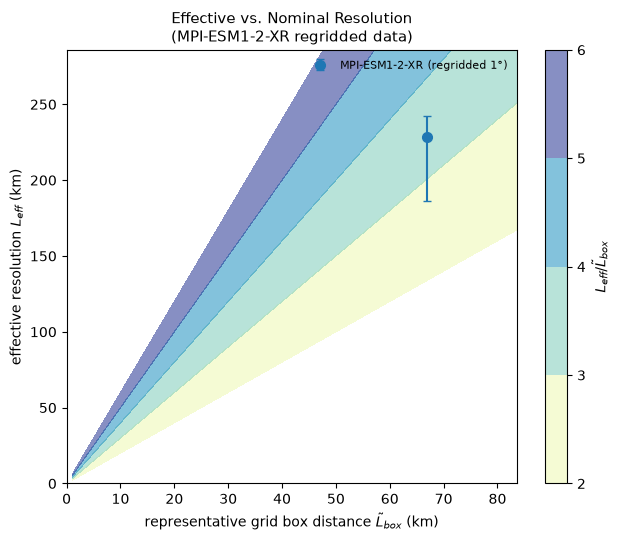


Note: This data point shows:
  - Grid box distance: 66.9 km (1° regridded grid)
  - Effective resolution: 228.7475837822945 (if None: insufficient steepening)
  - Only 1 of 3 spectra steepened (need 2+ for confirmation)

From Klaver et al. Table 1, native MPI-ESM1-2-XR should have:
  - Grid box distance: 79.6 km (TCO199 reduced Gaussian)
  - Effective wavenumber: l=79
  - Effective resolution: 253 km
  - Ratio: 3.2


In [15]:
from pcmdi_metrics.effective_resolution.lib import plot_resolution_scatter

# For this example, we only have one model configuration
# In practice, you would have multiple models or configurations to compare
ensemble = [result]
labels = ["MPI-ESM1-2-XR (regridded 1°)"]

# Note: The plot shows this is regridded data (not native grid)
# The effective resolution couldn't be determined (None) because only 1 spectrum steepened
# For proper analysis, use native grid data (gn) instead of regridded (gr)

fig = plot_resolution_scatter(
    ensemble, 
    labels=labels, 
    title="Effective vs. Nominal Resolution\n(MPI-ESM1-2-XR regridded data)"
)
plt.show()

print("\nNote: This data point shows:")
print(f"  - Grid box distance: {result['grid_box_distance_km']:.1f} km (1° regridded grid)")
print(f"  - Effective resolution: {result['effective_resolution_km']} (if None: insufficient steepening)")
print(f"  - Only 1 of 3 spectra steepened (need 2+ for confirmation)")
print("\nFrom Klaver et al. Table 1, native MPI-ESM1-2-XR should have:")
print("  - Grid box distance: 79.6 km (TCO199 reduced Gaussian)")
print("  - Effective wavenumber: l=79")
print("  - Effective resolution: 253 km")
print("  - Ratio: 3.2")